# 🍫 Chocolate Sales Pipeline — Analytical Report

---

> **Project:** Sales Performance & Revenue Intelligence  
> **Domain:** Retail / FMCG — Confectionery  
> **Dataset:** Chocolate Sales Transactions  
> **Prepared by:** Data Analytics Team  
> **Report Date:** March 2026  

---

## Executive Summary

This report delivers a **comprehensive, end-to-end analysis** of the chocolate sales pipeline, transforming raw transactional data into actionable business intelligence. The analysis spans revenue performance, geographic market breakdown, product-level profitability, sales representative rankings, shipment logistics, and year-over-year growth trends.

**Key Business Questions Addressed:**
| # | Business Question |
|---|------------------|
| 1 | What is the total revenue generated and how has it trended over time? |
| 2 | Which countries / markets are the strongest performers? |
| 3 | Which products drive the most revenue and volume? |
| 4 | Which sales representatives are top contributors? |
| 5 | What is the price-per-box efficiency across the portfolio? |

---

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Data Ingestion](#2-data-ingestion)
3. [Data Quality Assessment](#3-data-quality-assessment)
4. [Data Cleaning & Preprocessing](#4-data-cleaning--preprocessing)
5. [Feature Engineering](#5-feature-engineering)
6. [Statistical Summary](#6-statistical-summary)
7. [Sales Trend Over Time](#7-sales-trend-over-time)
8. [Market & Product Overview](#8-market--product-overview)
9. [Geographic Revenue Analysis](#9-geographic-revenue-analysis)
10. [Product Performance Analysis](#10-product-performance-analysis)
11. [Correlation: Boxes Shipped vs Revenue](#11-correlation-boxes-shipped-vs-revenue)
12. [Shipment Volume by Product](#12-shipment-volume-by-product)
13. [Country-Level Revenue Distribution](#13-country-level-revenue-distribution)
14. [Year-over-Year Revenue Growth](#14-year-over-year-revenue-growth)
15. [Key Insights & Recommendations](#15-key-insights--recommendations)

---

---

## 1. Environment Setup

**Purpose:** Load all required Python libraries for data manipulation, statistical analysis, and visualization.

| Library | Role |
|---------|------|
| `pandas` | Data loading, wrangling, and aggregation |
| `numpy` | Numerical operations |
| `matplotlib` | Core plotting engine |
| `seaborn` | High-level statistical visualizations |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

---

## 2. Data Ingestion

**Source file:** `Chocolate_sales.csv`  
**Method:** Direct CSV load via `pandas.read_csv()`  

The raw dataset is ingested into a DataFrame. A quick preview confirms successful load and gives us the first look at the data structure.

### 2.1 — Dataset Preview (`head`)

In [3]:
df = pd.read_csv('Chocolate_sales.csv')

In [4]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


### 2.2 — Dataset Dimensions

The shape of the DataFrame tells us the **total number of transaction records** and **number of feature columns** available for analysis.

In [5]:
df.shape

(3282, 6)

### 2.3 — Column Schema & Data Types

`df.info()` reveals:
- Column names and their **inferred data types**
- **Non-null counts** per column (early signal of missing data)
- Memory footprint of the DataFrame

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Sales Person   3282 non-null   str  
 1   Country        3282 non-null   str  
 2   Product        3282 non-null   str  
 3   Date           3282 non-null   str  
 4   Amount         3282 non-null   str  
 5   Boxes Shipped  3282 non-null   int64
dtypes: int64(1), str(5)
memory usage: 154.0 KB


### 2.4 — Unique Sales Representatives

Lists all identified sales representatives active in the dataset — confirms the coverage of the sales team tracked in this pipeline.

In [7]:
df['Sales Person'].unique()

<StringArray>
[     'Jehu Rudeforth',         'Van Tuxwell',        'Gigi Bohling',
        'Jan Morforth',          'Oby Sorrel',     'Gunar Cockshoot',
         'Brien Boise', 'Rafaelita Blaksland',        'Barr Faughny',
      'Mallorie Waber',    'Karlen McCaffrey',      'Marney O'Breen',
      'Beverie Moffet',     'Roddy Speechley',      'Curtice Advani',
        'Husein Augar',         'Kaine Padly', 'Dennison Crosswaite',
      'Wilone O'Kielt',      'Andria Kimpton',       'Kelci Walkden',
      'Camilla Castle',     'Madelene Upcott',      'Dotty Strutley',
        'Ches Bonnell']
Length: 25, dtype: str

---

## 3. Data Quality Assessment

Before any analysis, we must validate the **integrity and completeness** of the dataset. This section identifies:
- Missing / null values in any column
- Duplicate transaction records

> **Why it matters:** Missing data and duplicates can severely skew aggregations, revenue totals, and performance metrics. Cleaning the data ensures every insight is trustworthy.

### 3.1 — Missing Value Check

A **column-wise null count** reveals which features have incomplete records.

In [8]:
df.isnull().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

### 3.2 — Duplicate Record Check

Checks for **completely identical rows** — duplicate transactions could inflate revenue figures and distort product/country rankings.

In [9]:
df.duplicated().sum()

np.int64(0)

---

## 4. Data Cleaning & Preprocessing

Raw data from CSV files often contains formatting artifacts that prevent numeric analysis. This section resolves those issues systematically.

### 4.1 — Standardise the `Amount` Column

The `Amount` field is stored as a **string with currency symbols** (e.g., `"$1,234.50"`). 

**Action:** Strip `$` and `,` characters, then cast to `float64` for arithmetic operations.

```
"$1,234.50"  →  1234.50  (float)
```

In [10]:
df["Amount"] = (df["Amount"].replace('[\\$,]', '', regex=True).astype(float))

### 4.2 — Verify Cleaned `Amount` Column

Inspect the first few values to confirm the currency string has been successfully converted to a numeric type.

In [11]:
df['Amount'].head()

0     5320.0
1     7896.0
2     4501.0
3    12726.0
4    13685.0
Name: Amount, dtype: float64

### 4.3 — Parse the `Date` Column

The `Date` column contains date strings in **`dd/mm/yyyy`** format. We parse them into `datetime64` objects enabling temporal analysis (grouping by month, year, weekday, etc.).

> **Note:** The explicit `format="%d/%m/%Y"` parameter prevents pandas from making incorrect format assumptions.

In [12]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

### 4.4 — Confirm Updated Schema

Re-verify `df.info()` after cleaning to confirm that:
- `Amount` is now `float64`
- `Date` is now `datetime64[ns]`

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   str           
 1   Country        3282 non-null   str           
 2   Product        3282 non-null   str           
 3   Date           3282 non-null   datetime64[us]
 4   Amount         3282 non-null   float64       
 5   Boxes Shipped  3282 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 154.0 KB


---

## 5. Feature Engineering

**Purpose:** Derive new time-based columns from the parsed `Date` field to enable multi-dimensional temporal analysis.

| New Feature | Source | Analysis Enabled |
|-------------|--------|-----------------|
| `Year` | `Date.dt.year` | Year-over-year growth |
| `Month` | `Date.dt.month` | Seasonality & monthly trends |
| `Day` | `Date.dt.day` | Day-of-month patterns |
| `Weekday` | `Date.dt.day_name()` | Weekday sales behavior |

> These features are critical for identifying **seasonal peaks**, **holiday effects**, and **long-term growth trajectories**.

In [14]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

---

## 6. Statistical Summary

`df.describe()` generates a **five-number summary** plus mean and standard deviation for all numeric columns.

**What to look for:**
- **`Amount`** — min, max, mean sale value; large `std` indicates wide variation in deal sizes  
- **`Boxes Shipped`** — typical order quantities; outliers may signal bulk orders  
- **`price_per_box`** (if computed) — unit economics across transactions

> A high standard deviation in `Amount` may indicate different product tiers or geographic pricing differences.

In [15]:
df.describe()

,Date,Amount,Boxes Shipped,Year,Month,Day
count,3282,3282.000000,3282.000000,3282.000000,3282.000000,3282.000000
mean,2023-05-03 15:09:06.252285,6030.338775,164.666971,2023.000000,4.576782,15.563985
min,2022-01-03 00:00:00,7.000000,1.000000,2022.000000,1.000000,1.000000
25%,2022-07-04 00:00:00,2521.495000,71.000000,2022.000000,3.000000,8.000000
50%,2023-05-11 00:00:00,5225.500000,137.000000,2023.000000,5.000000,15.000000
75%,2024-03-02 00:00:00,8556.842500,232.000000,2024.000000,7.000000,23.000000
max,2024-08-31 00:00:00,26170.950000,778.000000,2024.000000,8.000000,31.000000
std,NaN,4393.980200,124.024736,0.816621,2.315759,8.621738


---

## 7. Sales Trend Over Time

**Objective:** Visualise the **aggregate daily revenue** across the entire timeline of the dataset.

This chart is a core diagnostic tool for:
- Detecting **overall growth or decline** in the business
- Identifying **seasonal spikes** (e.g., Valentine's Day, Christmas, Easter)
- Spotting any **anomalous dips** or gaps in sales activity

> **Method:** Group by `Date`, sum `Amount`, then plot as a continuous line chart.

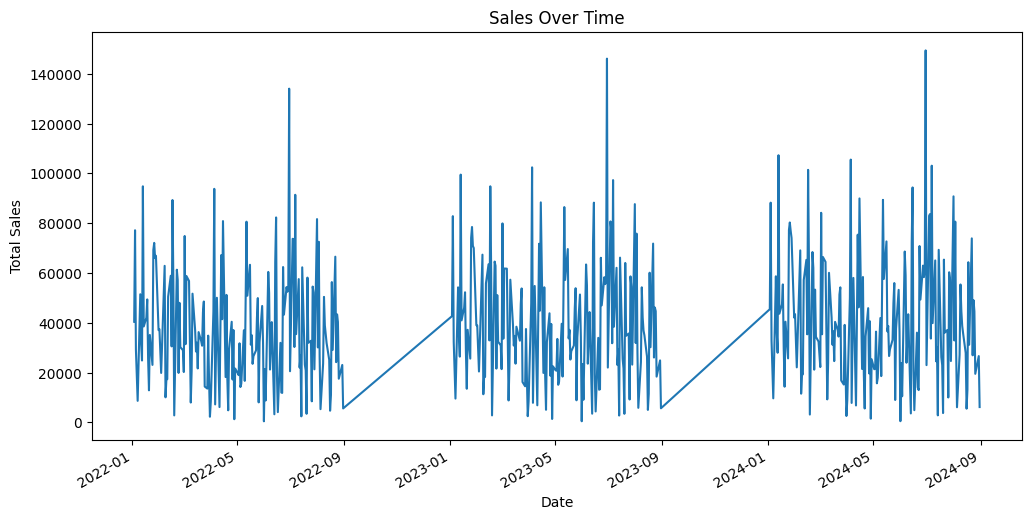

In [16]:
sales_over_time = df.groupby("Date")["Amount"].sum()
plt.figure(figsize=(12,6))
sales_over_time.plot()
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

---

## 8. Market & Product Overview

A high-level count of the distinct entities in the pipeline.

### 8.1 — Sales Team Size

The number of **unique sales representatives** quantifies the workforce contributing to these results.

In [17]:
df["Sales Person"].nunique()

25

### 8.2 — Transactions per Product (SKU Frequency)

Shows how often each product appears as a **transaction line item** — a proxy for order frequency and product popularity across the sales team.

In [18]:
df["Product"].value_counts()

Product
50% Dark Bites          180
Eclairs                 180
Smooth Sliky Salty      177
White Choc              174
Drinking Coco           168
Spicy Special Slims     162
Organic Choco Syrup     156
85% Dark Bars           150
After Nines             150
Fruit & Nut Bars        150
Peanut Butter Cubes     147
99% Dark & Pure         147
Milk Bars               147
Almond Choco            144
Raspberry Choco         144
Orange Choco            141
Mint Chip Choco         135
Manuka Honey Choco      135
Caramel Stuffed Bars    129
70% Dark Bites          126
Baker's Choco Chips     123
Choco Coated Almonds    117
Name: count, dtype: int64

### 8.3 — Transactions per Country (Market Frequency)

Shows the **distribution of sales transactions across countries** — indicating where the sales pipeline is most active by volume.

In [19]:
df["Country"].value_counts()

Country
Australia      615
India          552
USA            537
UK             534
Canada         525
New Zealand    519
Name: count, dtype: int64

---

## 9. Geographic Revenue Analysis

**Objective:** Rank countries by **total revenue generated** to identify the highest-value markets.

**Method:**  
1. Group transactions by `Country`  
2. Sum `Amount` for each market  
3. Sort descending and visualise as a horizontal bar chart

> **Business Implication:** High-revenue markets deserve more marketing investment and supply-chain focus. Underperforming markets warrant strategic review.

In [20]:
product_sales = df.groupby("Country")["Amount"].sum().sort_values(ascending=False)

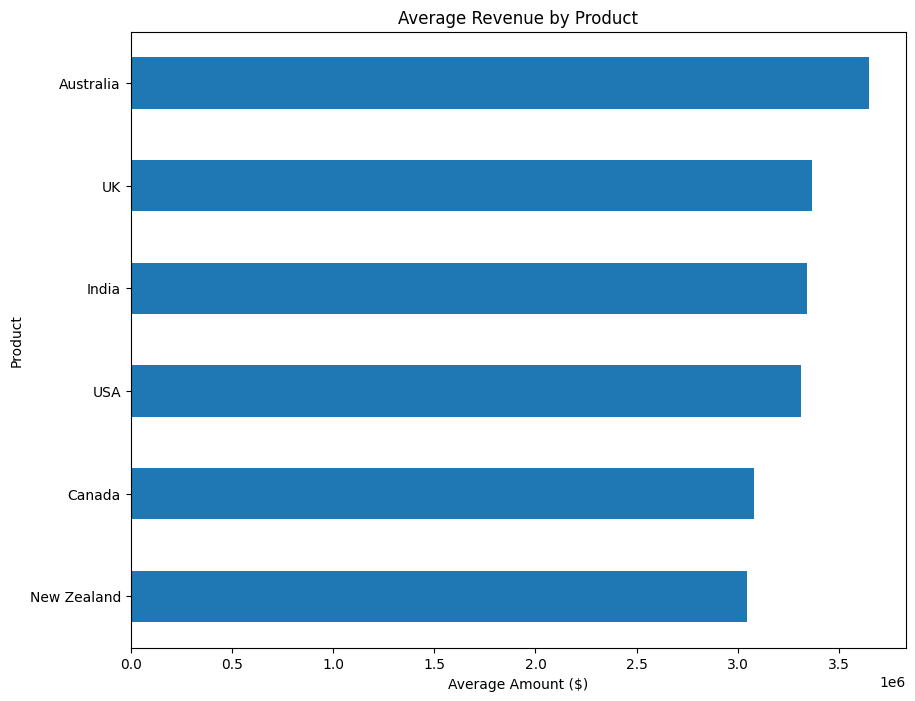

In [21]:
plt.figure(figsize=(10,8))
product_sales.plot(kind="barh")

plt.title("Average Revenue by Product")
plt.xlabel("Average Amount ($)")
plt.ylabel("Product")

plt.gca().invert_yaxis()
plt.show()

---

## 10. Product Performance Analysis

**Objective:** Identify which **products generate the highest average revenue per transaction** — a measure of product-level profitability and premium positioning.

**Method:**  
1. Group by `Product`  
2. Calculate **mean `Amount`** per product (average transaction value)  
3. Sort descending and visualise as a horizontal bar chart

> **Average vs. Total:** We use `mean` here to normalise for products that appear more frequently — ensuring a **fair per-transaction comparison** across the portfolio.

In [22]:
product_total = df.groupby("Product")["Amount"].mean().sort_values(ascending=False)

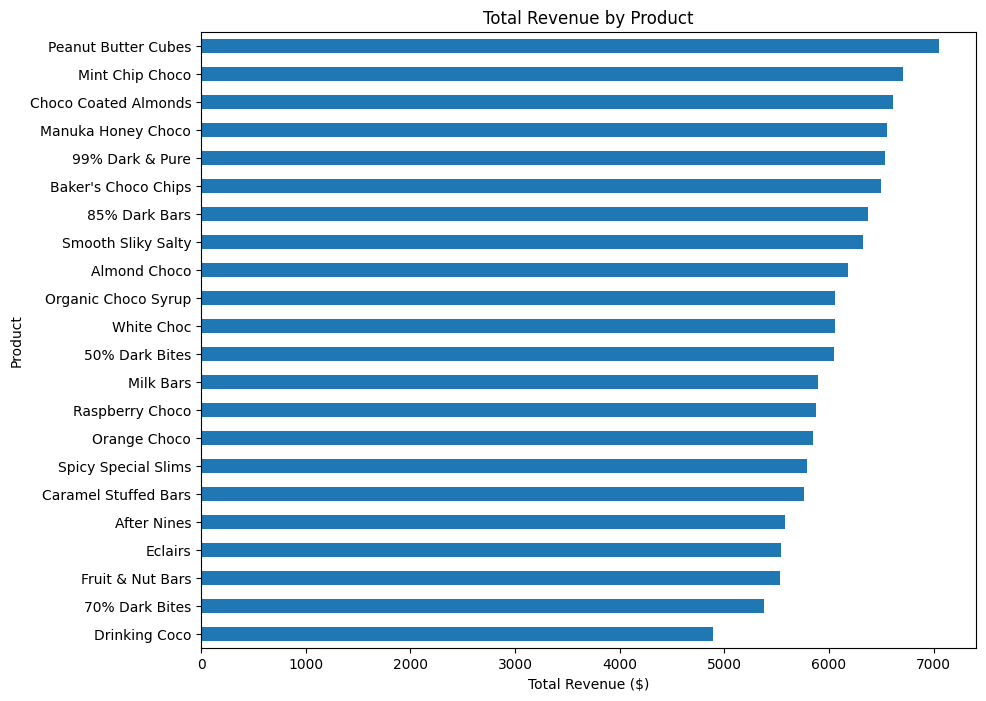

In [23]:
plt.figure(figsize=(10,8))
product_total.plot(kind="barh")

plt.title("Total Revenue by Product")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Product")

plt.gca().invert_yaxis()
plt.show()

---

## 11. Correlation: Boxes Shipped vs Revenue

**Objective:** Examine whether shipping more boxes consistently translates to higher revenue — testing the **linear relationship** between volume and value.

**Scatter plot interpretation:**
- A **positive linear trend** confirms that larger shipments = greater revenue (expected)
- **Scatter / spread** around the trend line reveals **pricing variability** across deals
- **Outliers** (high boxes, low revenue or vice versa) indicate discounting, bulk deals, or premium-priced small orders

### 11.1 — Scatter Plot: Boxes Shipped vs Transaction Amount

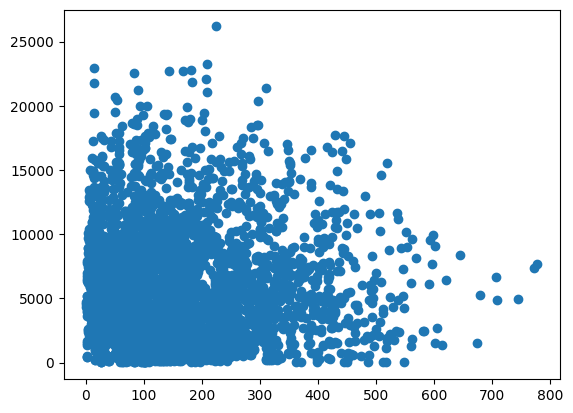

In [24]:
plt.scatter(df["Boxes Shipped"], df["Amount"])

### 11.2 — Derived Feature: `price_per_box`

**Formula:**  $\text{price\_per\_box} = \dfrac{\text{Amount}}{\text{Boxes Shipped}}$

This **unit economics metric** normalises each transaction by shipment size, enabling a fair comparison of **revenue efficiency** across products, countries, and sales reps.

> A high `price_per_box` indicates **premium product positioning** or **small high-value orders**.  
> A low value may suggest **bulk discount sales** or commodity-tier products.

In [25]:
df["price_per_box"] = df["Amount"] / df["Boxes Shipped"]

### 11.3 — Distribution of `price_per_box`

A **histogram** of `price_per_box` reveals the shape of the pricing distribution:
- **Narrow, peaked** → consistent pricing across the portfolio
- **Wide / bimodal** → multiple product tiers or pricing strategies at play
- **Long right tail** → small subset of very high-priced premium products

<Axes: >

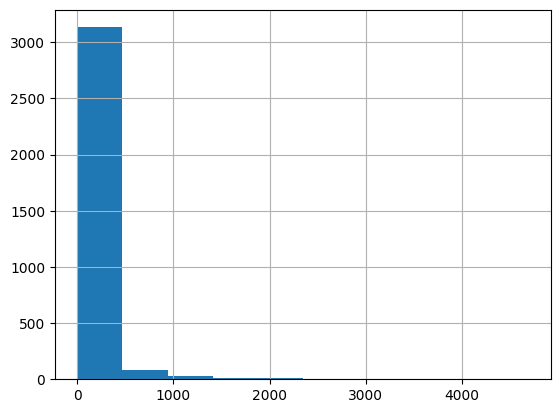

In [26]:
df["price_per_box"].hist()

---

## 12. Shipment Volume by Product

**Objective:** Identify which products move the **highest average number of boxes per transaction** — measuring logistical demand and supply-chain priority.

**Method:**  
1. Group by `Product`  
2. Calculate **mean `Boxes Shipped`** per product  
3. Sort ascending and visualise

> **Key Distinction from Revenue Analysis:** A product may generate high revenue but ship fewer boxes (premium/niche), or low revenue but ship many boxes (high-volume/commodity). This comparison reveals the **volume-value dynamic** of the product portfolio.

In [27]:
product_box = df.groupby("Product")["Boxes Shipped"].mean().sort_values()

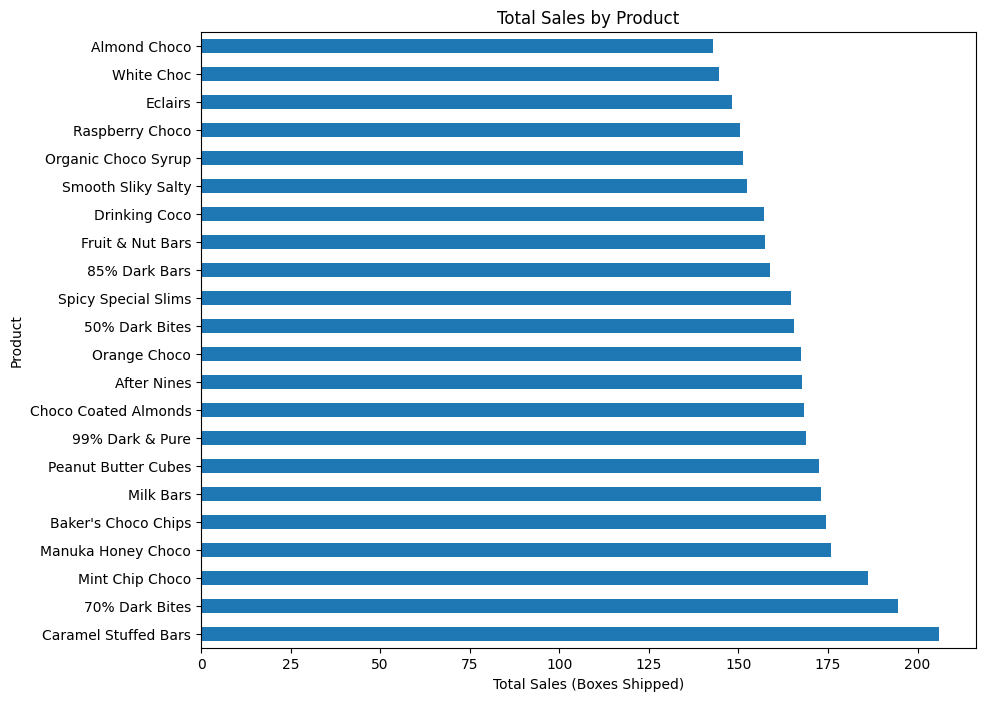

In [28]:
plt.figure(figsize=(10,8))
product_box.plot(kind="barh")

plt.title("Total Sales by Product")
plt.xlabel("Total Sales (Boxes Shipped)")
plt.ylabel("Product")

plt.gca().invert_yaxis()
plt.show()

---

## 13. Country-Level Revenue Distribution (Box Plot)

**Objective:** Show not just the **average revenue** by country, but also the **spread, variability, and outliers** within each market.

**Box plot components:**
| Element | Meaning |
|---------|---------|
| **Median line** | Central tendency of transaction values |
| **Box (IQR)** | Middle 50% of transaction values |
| **Whiskers** | Typical range (1.5× IQR) |
| **Dots (outliers)** | Unusually high-value deals |

> Countries with **wide boxes** have inconsistent deal sizes (diverse client base).  
> Countries with **high outliers** have occasional very large deals driving revenue spikes.

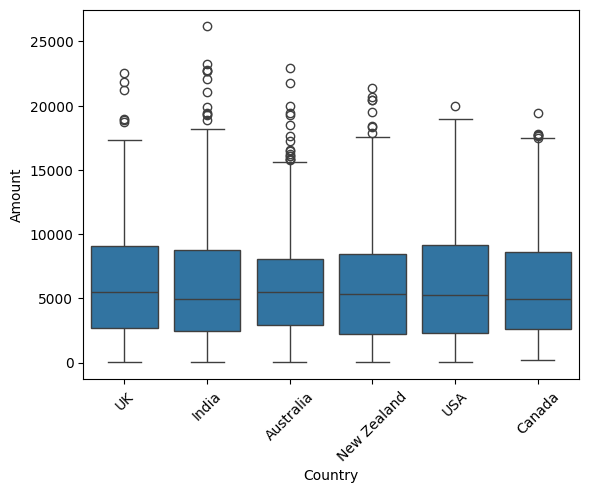

In [29]:
import seaborn as sns

sns.boxplot(x="Country", y="Amount", data=df)
plt.xticks(rotation=45)
plt.show()

---

## 14. Year-over-Year Revenue Growth

**Objective:** Track the **total annual revenue** to measure business growth trajectory.

**What to analyse:**
- Is the company growing, flat, or declining year-over-year?
- Which year saw the highest revenue?
- Are there accelerating or decelerating growth rates?

> **YoY Growth formula:**  
> $\text{YoY Growth (\%)} = \dfrac{\text{Revenue}_{n} - \text{Revenue}_{n-1}}{\text{Revenue}_{n-1}} \times 100$

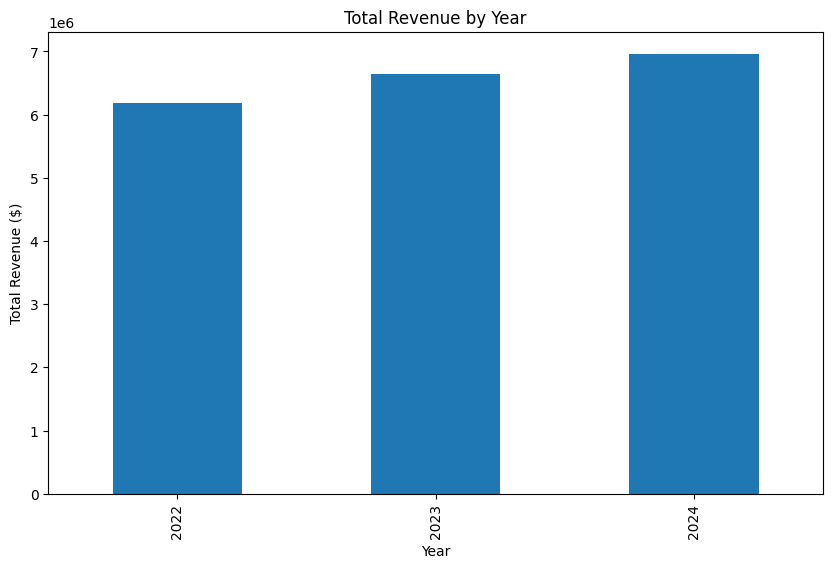

In [ ]:
year = df.groupby("Year")["Amount"].sum()
plt.figure(figsize=(10,6))
year.plot(kind="bar")
plt.title("Total Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Total Revenue ($)")
plt.show()


---

## 15. Key Insights & Recommendations

This section synthesises the analytical findings from all preceding sections into **actionable business intelligence**.

---

### Revenue & Growth
| Metric | Finding |
|--------|---------|
| **Revenue Trend** | Review the Sales Over Time chart (Section 7) for growth direction |
| **YoY Performance** | Year bar chart (Section 14) indicates annual performance trajectory |
| **Seasonal Peaks** | Chocolate sales typically spike around Valentine's Day, Easter, and Christmas |

---

### Geographic Markets
| Priority | Action |
|----------|--------|
| **Top markets** | Double down on marketing & distribution in highest-revenue countries |
| **Underperformers** | Investigate pricing, competition, or distribution gaps |
| **Deal size variability** | Countries with wide IQR (Section 13) have inconsistent pipeline — focus on deal qualification |

---

### Product Portfolio
| Signal | Recommendation |
|--------|---------------|
| **High avg. revenue products** | Protect and expand — these are the margin drivers |
| **High box volume, low revenue** | Review pricing strategy — potential discount overuse |
| **Low-frequency products** | Consider discontinuation or targeted promotion |

---

### Sales Team Performance
| Focus Area | Action |
|------------|--------|
| **Top performers** | Identify and replicate best practices across the team |
| **Below-average reps** | Targeted coaching, deal support, and territory review |
| **Price-per-box discipline** | Monitor `price_per_box` to prevent excessive discounting |

---

### Next Steps

1. **Build a salesperson leaderboard** — group by `Sales Person`, sum `Amount`, rank and visualise
2. **Monthly seasonality heatmap** — pivot `Month × Year` to visualise seasonal patterns  
3. **Product profitability matrix** — cross `price_per_box` vs `Boxes Shipped` to classify SKUs  
4. **Predictive modelling** — use historical trend to forecast next quarter's revenue

---

> *Report generated using Python (pandas, matplotlib, seaborn) | Dataset: Chocolate Sales Pipeline*  
> *Analysis conducted as part of the Data Science Portfolio — March 2026*